# Customer Purchasing Behaviours

https://www.kaggle.com/datasets/hanaksoy/customer-purchasing-behaviors/data

## EDA (Exploratory Data Analysis)

### Preparing the dataset

In [22]:
#Installation of Packages
#pip install pandas

In [23]:
# Importing Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
"""
Used url in the github repo so that the code is very reproducible by anyone.
"""

url = "https://github.com/hamedabangar/customer_purchasing_behaviors/raw/main/data/raw/Customer%20Purchasing%20Behaviors.csv"

df = pd.read_csv(url)
df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


### Quick Overview 

In [25]:
df.shape

(238, 7)

This dataset has 238 rows and 7 columns

In [26]:
#check for null
df.isnull().sum()

user_id               0
age                   0
annual_income         0
purchase_amount       0
loyalty_score         0
region                0
purchase_frequency    0
dtype: int64

There are no null values

In [27]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

There are 0 duplicated values 

### Reorganization of Columns

Decided to reorganize the columns for better readability.

For instance, data concerning customer's characteristics (age, region) were first then transactional data in the later parts. 

In [28]:
#re-organizing columns
df = df[['user_id', 'region', 'age', 'annual_income', 
         'loyalty_score', 'purchase_amount', 'purchase_frequency']]

It appears that as a business, our objective is to **maximize purchase amount and purchase frequency.**

Create new label/colunn **purchase_total**
which can be derived by purchase_amount * purchase_frequency. 
<br>

As a business, our objective would be to maximize purchase_total ; which can be achieved by increasing purchase_amount and purchase_frequency

In [29]:
df['purchase_total'] = df['purchase_amount'] * df['purchase_frequency']

### Preliminary Analysis

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   region              238 non-null    object 
 2   age                 238 non-null    int64  
 3   annual_income       238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   purchase_amount     238 non-null    int64  
 6   purchase_frequency  238 non-null    int64  
 7   purchase_total      238 non-null    int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 15.0+ KB


In [31]:
"""
Note about 'describe':
describe() does not assume or imply a bell-curve (normal) distribution.
"""

df.describe().T #T -> Transpose (flips rows and columns) 

,count,mean,std,min,25%,50%,75%,max
user_id,238.0,119.500000,68.848868,1.0,60.25,119.5,178.750,238.0
age,238.0,38.676471,9.351118,22.0,31.00,39.0,46.750,55.0
annual_income,238.0,57407.563025,11403.875717,30000.0,50000.00,59000.0,66750.000,75000.0
loyalty_score,238.0,6.794118,1.899047,3.0,5.50,7.0,8.275,9.5
purchase_amount,238.0,425.630252,140.052062,150.0,320.00,440.0,527.500,640.0
purchase_frequency,238.0,19.798319,4.562884,10.0,17.00,20.0,23.000,28.0
purchase_total,238.0,9059.033613,4597.704379,1500.0,5200.00,9000.0,12132.500,17920.0


<u>Column's Range and Mean</u> <br>
**Age** : range from 22 to 55 ; mean = 39 <br>
**Annual Income** : range from $30,000 to $75,000 ; mean = $57,407.56 <br>
**Loyalty Score** : range from 3.0 to 9.5 ; mean = 6.8 <br>
**Purchase Amount** : range from $150 to $640 ; mean = $42 <br>
**Purcase Frequency** : range from 10 to 28 ; mean = 20 <br>
**Purchase Total** : range $1500 to $17,920 ; mean = $9059.03 <br>

In [32]:
region_stats = pd.DataFrame({
    'Count': df['region'].value_counts(),
    'Percentage': df['region'].value_counts(normalize=True) * 100
})

region_stats['Percentage'] = region_stats['Percentage'].round(1).astype(str) + '%'

region_stats


,Count,Percentage
region,,
North,78,32.8%
South,77,32.4%
West,77,32.4%
East,6,2.5%


Though there are some imbalances, at this moment in time, **no balancing is needed unless region becomes the label**

### Initial Hypothesis

In [33]:
region_summary = df.groupby('region').agg({
    'user_id': 'count',
    'age': 'mean',
    'annual_income': 'mean',
    'loyalty_score': 'mean',
    'purchase_amount': 'mean',
    'purchase_frequency': 'mean',
    'purchase_total': 'mean'
}).rename(columns={'user_id': 'Count'})

# Round all numeric columns to 2 decimals
region_summary = region_summary.round(2)

region_summary

,Count,age,annual_income,loyalty_score,purchase_amount,purchase_frequency,purchase_total
region,,,,,,,
East,6,31.67,49000.00,5.40,320.00,16.67,5830.00
North,78,34.36,53038.46,5.87,358.59,17.65,6796.28
South,77,38.00,55766.23,6.73,416.88,19.47,8750.39
West,77,44.27,64129.87,7.91,510.52,22.55,11911.43


Based on a quick glance, we can observe that counts of North, South, West is almost similar in counts of instances. Therefore, it is easy to make a direct comparison between North, South, West.
<br><br>
We can observe that West has highest average age, annual income, loyalty score, purchase amount, frequency and purchase total. ALL the variables are highest in 'West'. 
<br><br>
West > South > North ; this pattern is consistent throughout the dataset for ALL corresponding columns
<br><br>
Therefore, we can safely initially hypothesize that: <br>
"There appears to be a direct correlation between age and income. Higher the age, higher the income. And higher income determines that the loyalty score is higher, purchase amount is higher, purchase frequency is higher.
<br> 
Therefore, the focus should be to have clients with higher incomes. And, it happens that higher age clients have higher incomes. "

### Correlation

In [34]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Display
corr_matrix

,user_id,age,annual_income,loyalty_score,purchase_amount,purchase_frequency,purchase_total
user_id,1.000000,0.067061,0.059031,0.060819,0.080621,0.070541,0.073590
age,0.067061,1.000000,0.974833,0.981835,0.986140,0.980532,0.991009
annual_income,0.059031,0.974833,1.000000,0.984351,0.984208,0.982920,0.966854
loyalty_score,0.060819,0.981835,0.984351,1.000000,0.994147,0.986990,0.978267
purchase_amount,0.080621,0.986140,0.984208,0.994147,1.000000,0.993579,0.988883
purchase_frequency,0.070541,0.980532,0.982920,0.986990,0.993579,1.000000,0.987954
purchase_total,0.073590,0.991009,0.966854,0.978267,0.988883,0.987954,1.000000


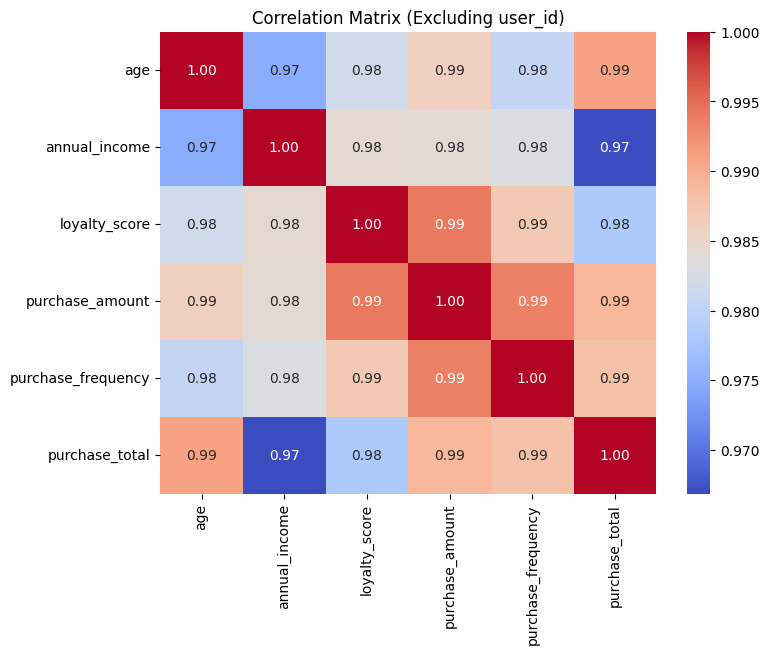

In [35]:
corr_matrix = df.drop(columns=['user_id']).corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Excluding user_id)')
plt.show()

The correlation matrix shows that the numeric features in the dataset are highly positively correlated with each other. 

Age, annual income, loyalty score, purchase amount, purchase frequency, and purchase total all exhibit correlations close to 0.97–0.99; almost perfect correlation. 

While strong correlations can provide useful insights, they also indicate multicollinearity (meaning some features capture very similar information). 

In our case, high income means high resultants.

### Visualizations

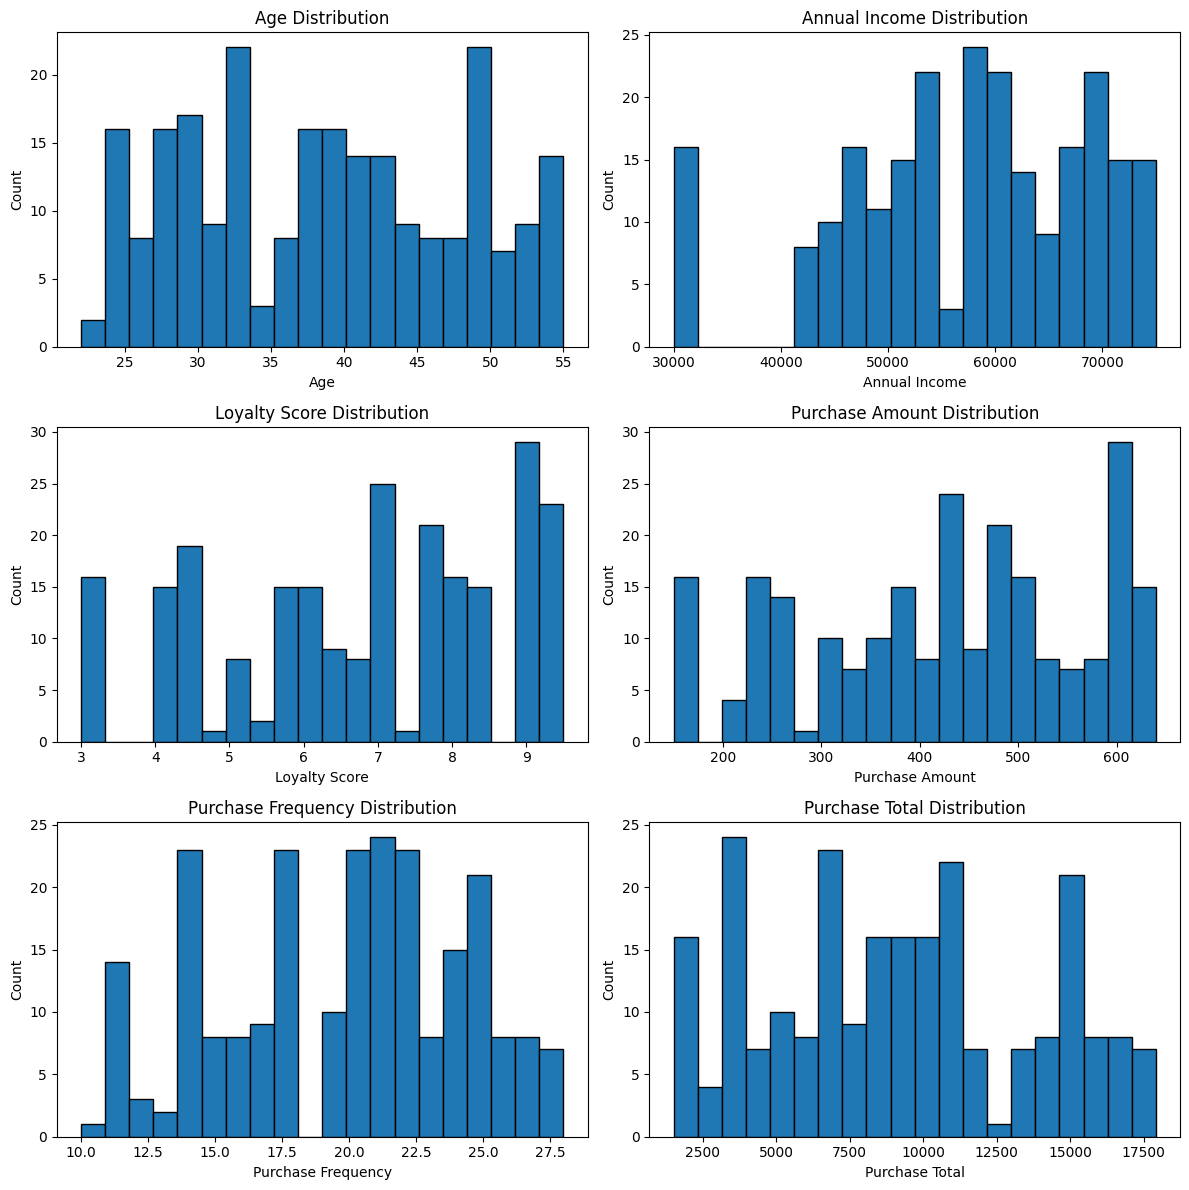

In [40]:
"""Visualizations of Distributions of Numeric Features"""

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

columns = [
    'age',
    'annual_income',
    'loyalty_score',
    'purchase_amount',
    'purchase_frequency',
    'purchase_total'
]

for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=20, edgecolor='black')
    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

From observing the last 3 graphs (Purchase Amount, Purchase Frequency, Purchase Total): 

Since purchase total is the product of the two (amount * frequency), all three variables are highly positively correlated.

Customers who spend more per purchase or buy more frequently and especially those who do both, generate much higher purchase totals.

Therefore, we'd like to focus on customers who spend frequently and alot. 

***Most graphs seems to be of even distribution. However, by subsetting the data, we have uncovered discoveries that will be helpful for the business case by focusing on high frequency and high spending shoppers***

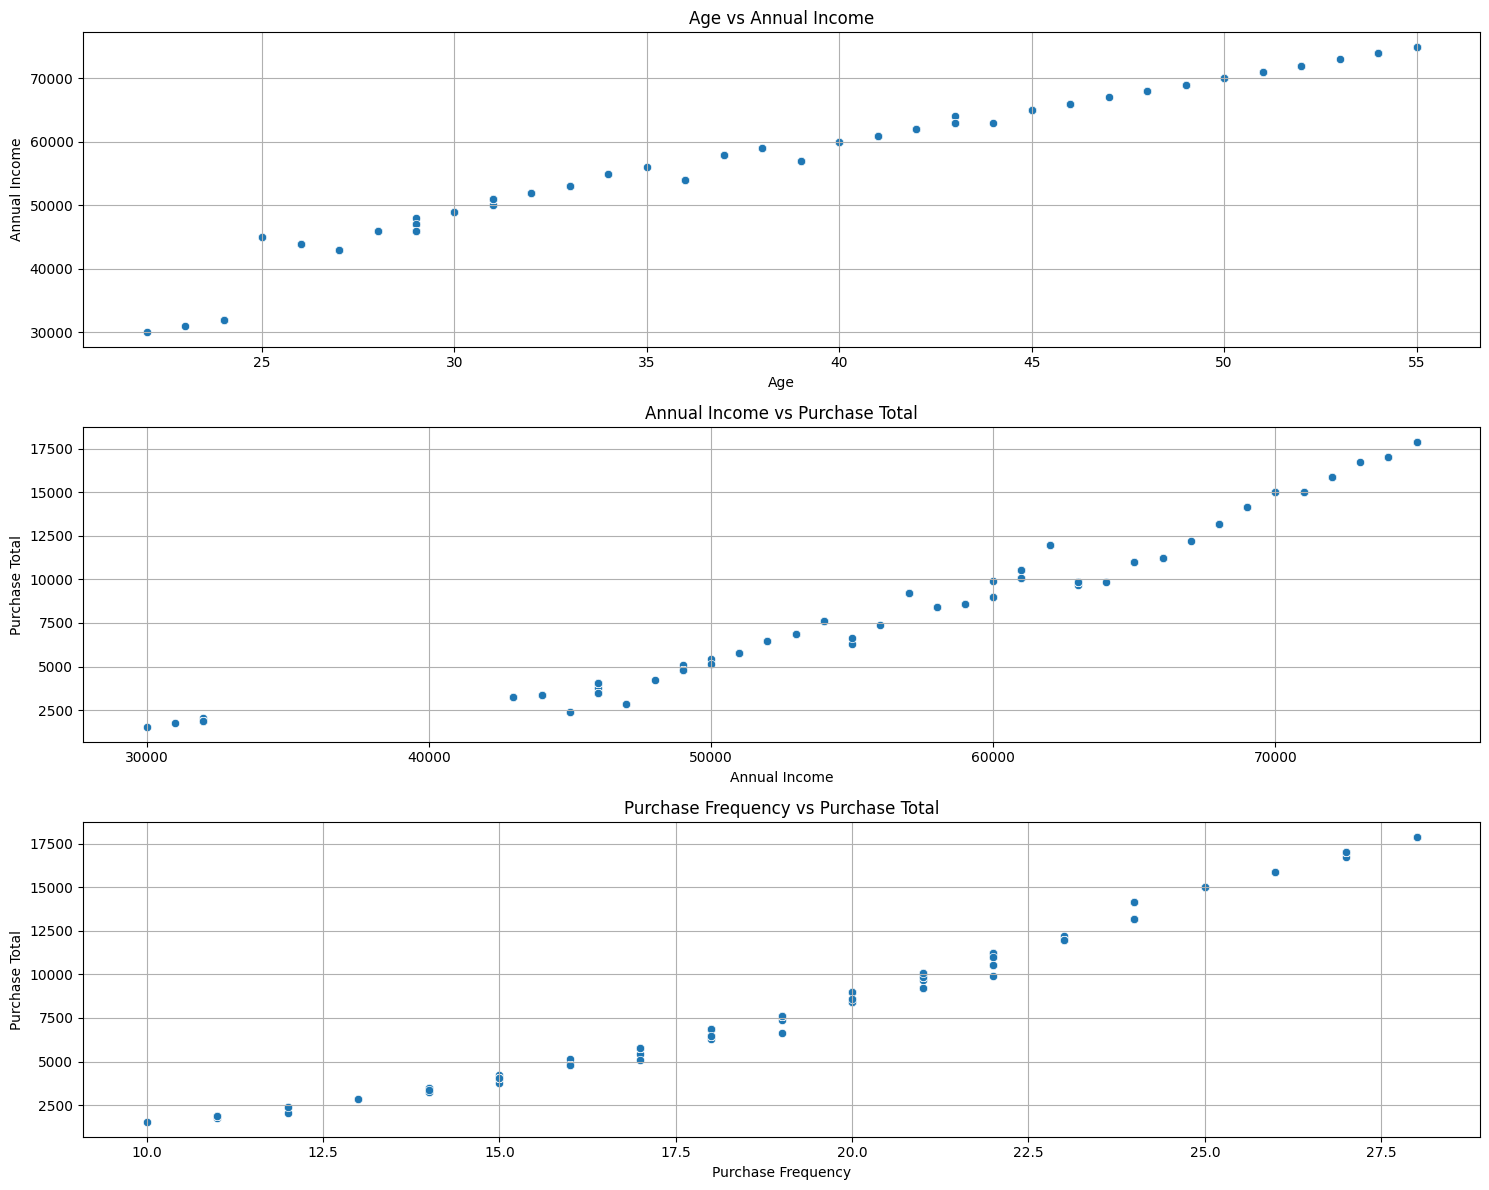

In [41]:
plt.figure(figsize=(15, 12))

# 1. Age vs Annual Income
plt.subplot(3, 1, 1)
sns.scatterplot(data=df, x='age', y='annual_income')
plt.title('Age vs Annual Income')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.grid(True)

# 2. Annual Income vs Purchase Total
plt.subplot(3, 1, 2)
sns.scatterplot(data=df, x='annual_income', y='purchase_total')
plt.title('Annual Income vs Purchase Total')
plt.xlabel('Annual Income')
plt.ylabel('Purchase Total')
plt.grid(True)

# 3. Purchase Frequency vs Purchase Total
plt.subplot(3, 1, 3)
sns.scatterplot(data=df, x='purchase_frequency', y='purchase_total')
plt.title('Purchase Frequency vs Purchase Total')
plt.xlabel('Purchase Frequency')
plt.ylabel('Purchase Total')
plt.grid(True)

plt.tight_layout()
plt.show()

***Age vs Income*** <br>
Almost perfectly linear correlation except for age ~25 to 27. Therefore, it can be assumed that higher age clients have higher income

***Annual Income vs Purchase Total*** <br>
Outliers at the bottom (~$30,000 to $32,000) but other than that, there is a very strong positive correlation between income and purcahses. Therefore, it can be assumed that higher income clients make more purchases.

***Purchase Freqeuency vs Purchase Total***
There are no outliers with this relationship. There is a very strong positive correlation between frequency and purchase total. Therefore, it can be assumed that clients that purchase more frequently also purchase more per purchase, hence, higher purchase total. 


### Subset of data of high frequency shoppers

Looking at the 'Purchase Frequency Distribution', we want to focus on characteristics of high frequency purchase clients (75th percentile or higher)

In [43]:
#subset of data of high freqeuncy customers
high_freq_df = df[df['purchase_frequency'] > df['purchase_frequency'].quantile(0.75)]

#data cleaning of high frequency customers
high_freq_summary = (
    high_freq_df
    .drop(columns=['user_id'])
    .mean(numeric_only=True)
    .round(2)
)

high_freq_summary

age                      51.14
annual_income         71135.59
loyalty_score             9.07
purchase_amount         602.71
purchase_frequency       25.51
purchase_total        15403.56
dtype: float64

**Summary of High Frequency Shoppers**

We are able to conclude that though 'age' is an even distribution, higher age clients >51 are the ones purchasing frequently (75th percentile or larger). 

They also happen to be higher income (>$71,000), very high loyalty (>9), high spenders who spend more frequently at higher amounts (hence, also impacting purchase totals)



### Subset of data of loyal customers

There will be 2 categories created: high loyalty (=>8) and low (<8)

An analysis will be done to see if there is a distinction between low and high loyalty customers.

In [48]:
df['loyalty_category'] = pd.cut(
    df['loyalty_score'],
    bins=[0, 8, float('inf')],
    labels=['Low (0–8)', 'High (8+)'],
    right=False
)

loyalty_group_summary = df.groupby('loyalty_category').mean(numeric_only=True)
loyalty_group_summary

loyalty_group_summary = (
    df.drop(columns=['user_id'])
      .groupby(df['loyalty_category'])
      .mean(numeric_only=True)
)
loyalty_group_summary

C:\Users\kyuhw\AppData\Local\Temp\ipykernel_3692\1598997675.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loyalty_group_summary = df.groupby('loyalty_category').mean(numeric_only=True)
C:\Users\kyuhw\AppData\Local\Temp\ipykernel_3692\1598997675.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(df['loyalty_category'])


,age,annual_income,loyalty_score,purchase_amount,purchase_frequency,purchase_total
loyalty_category,,,,,,
Low (0–8),33.025806,51077.419355,5.726452,345.096774,17.232258,6281.096774
High (8+),49.228916,69228.915663,8.787952,576.024096,24.590361,14246.746988


C:\Users\kyuhw\AppData\Local\Temp\ipykernel_3692\2162814276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loyalty_category', y=col, palette='Set2')
C:\Users\kyuhw\AppData\Local\Temp\ipykernel_3692\2162814276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loyalty_category', y=col, palette='Set2')
C:\Users\kyuhw\AppData\Local\Temp\ipykernel_3692\2162814276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loyalty_category', y=col, palette='Set2')
C:\Users\kyuhw\AppData\Local\Temp\ipykernel_3692\

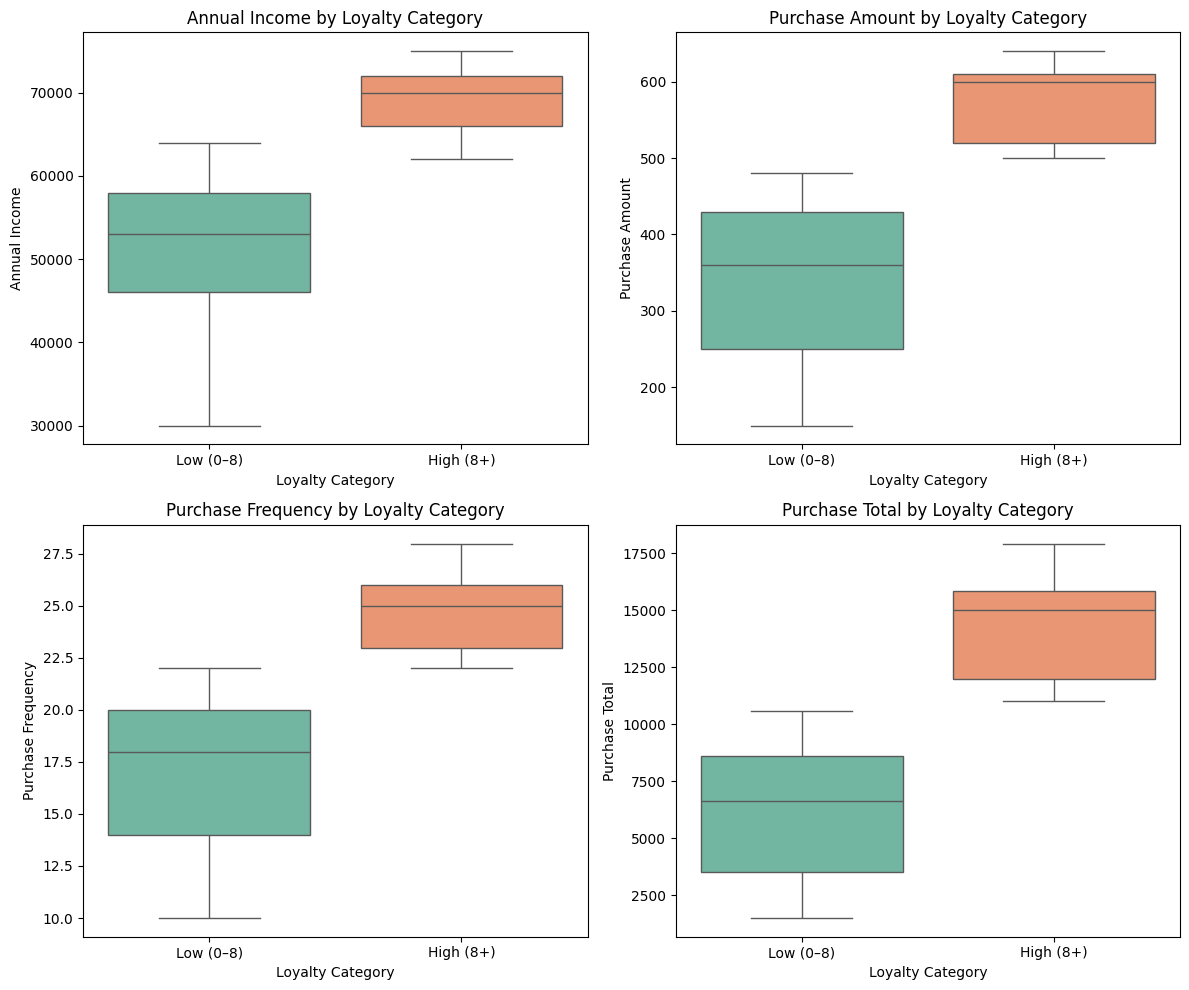

In [50]:
"""Visualizations comparing low and high loyalty customers"""

cols = ['annual_income', 'purchase_amount', 'purchase_frequency', 'purchase_total']

plt.figure(figsize=(12, 10))

for i, col in enumerate(cols, start=1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='loyalty_category', y=col, palette='Set2')
    plt.title(f'{col.replace("_", " ").title()} by Loyalty Category')
    plt.xlabel('Loyalty Category')
    plt.ylabel(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

High Loyalty -> Orange Box Plot
Low Loyalty -> Green Box Plot

We can conclude that there is a distinction between low and high loyalty customers. We can see that high loyalty customers have higher incomes, higher spending, higher frequency. 

Therefore, the business should definately focus on higher loyalty customers!

## Machine Learning

### Classification

A classification question that we can try exploring to answer:

***"Can we predict which region a customer belongs to based on their purchasing patterns and demographics?"***

In [ ]:
#region data breakdown (code block found above)
region_stats

,Count,Percentage
region,,
North,78,32.8%
South,77,32.4%
West,77,32.4%
East,6,2.5%


When answering this classification problem, we run into a problem where there are imbalances with the data. 'East' is a region where there are not enough samples which creates a class imbalance problem. 

Since other regions are well balances, we will attempt to balance the dataset (sepcifically with 'East') since ***region now becomes label for this problem.***



Some terminiology and concepts to help address this issue:

"***SMOTE*** or Synthetic Minority Oversampling Technique is a machine learning method used to address imbalanced datasets by generating new, synthetic samples for the minority class."

"***Oversampling*** is a technique that temporarily increases the sample rate of a signal. SMOTE is an oversampling technique"

We will be using SMOTE to address the issue since the dataset is already small (undersampling would be a bad idea). 

However, SMOTE will only examine existing East points. Uses algorithim nearest neighbours within East class only. 

In [59]:
#packages for classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

In [60]:
"""Preparing Data for Classification (Features and Target)"""

#copy for ml
df_ml = df.copy()

#Label (Region)
y = df_ml['region']

#Features (numeric only recommended)
X = df_ml[['age', 'annual_income', 'loyalty_score',
           'purchase_amount', 'purchase_frequency', 'purchase_total']]

In [61]:
"""Train/Test Split"""

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y   # keeps 'Region' ratios in test set
)

Notice the parameter 'stratify' with the label region. Simply put, when we split the dataset, we want to keep the ratio of North, South, East, West equal for both training and testing. 

In [65]:
""""
SMOTE for Balancing Classes

default value for smote is k = 5.
However, the smallest class has only 4 samples in the training set.
Therefore, we set k = 1.
"""

smote = SMOTE(random_state=42, k_neighbors=1) #k_neighbors set to 1 
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_res.value_counts())

Before SMOTE: region
West     58
South    58
North    58
East      4
Name: count, dtype: int64

After SMOTE: region
West     58
South    58
North    58
East     58
Name: count, dtype: int64


In [66]:
"""
Train the Model

"A Random Forest Classifier is an ensemble learning method used for classification tasks. 
It operates by constructing a multitude of decision trees during training and outputting 
the class that is the mode of the classes (majority vote) of the individual trees."

In English, random forest, is a machine learning method that makes predictions by combining
the results of many decision trees instead of just relying on one. Then the algorithm picks
the best one. 

Even simplier explanation. A single decision tree is like asking one friend for advice.
Random forest is like asking a group of friends and going with the majority opinion.
"""

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=None  # SMOTE already balances data
)

model.fit(X_train_res, y_train_res)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
"""Evaulate the Model"""

y_pred = model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

        East       0.00      0.00      0.00         2
       North       0.71      0.85      0.77        20
       South       0.89      0.84      0.86        19
        West       0.83      0.79      0.81        19

    accuracy                           0.80        60
   macro avg       0.61      0.62      0.61        60
weighted avg       0.78      0.80      0.79        60


Confusion Matrix:

[[ 0  2  0  0]
 [ 0 17  0  3]
 [ 0  3 16  0]
 [ 0  2  2 15]]


c:\Users\kyuhw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kyuhw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kyuhw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

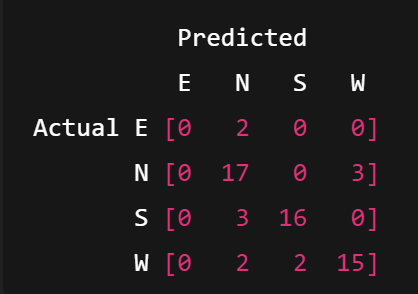

Result: With test of 2 'East' points, the model guessed 'North' instead. 

It appears that the model completely fails to predit the "East" region; even after SMOTE. 

Possible reason: 
There were 4 real 'East' data points. SMOTE synthetically interpolated those 4 points -> model has no ability to generalize from just 4 original points. 

***
Model Result Overall: 
The region classificaiton is NOT feasible with current dataset with severe class imbalance and insufficient real samples for East region. However, the model does a good job of predicting 'North', 'South', 'West'. 
***